In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/daily_recovery_dataset.csv", parse_dates=["date"])
df.info()

Matplotlib is building the font cache; this may take a moment.


<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   cycle_id               440 non-null    int64         
 1   date                   440 non-null    datetime64[us]
 2   score_state            440 non-null    str           
 3   strain                 440 non-null    float64       
 4   kilojoule              440 non-null    float64       
 5   avg_heart_rate         440 non-null    int64         
 6   max_heart_rate         440 non-null    int64         
 7   sleep_id               430 non-null    str           
 8   recovery_score         430 non-null    float64       
 9   resting_heart_rate     430 non-null    float64       
 10  hrv_rmssd_milli        430 non-null    float64       
 11  spo2_percentage        428 non-null    float64       
 12  skin_temp_celsius      428 non-null    float64       
 13  user_calibrating

In [2]:
df.isna().sum().sort_values(ascending=False)

spo2_percentage          12
skin_temp_celsius        12
nap                      10
respiratory_rate         10
rem_sleep_hours          10
deep_sleep_hours         10
light_sleep_hours        10
disturbance_count        10
awake_ms                 10
rem_sleep_ms             10
deep_sleep_ms            10
light_sleep_ms           10
sleep_efficiency_pct     10
sleep_consistency_pct    10
sleep_performance_pct    10
awake_hours              10
user_calibrating         10
hrv_rmssd_milli          10
resting_heart_rate       10
recovery_score           10
sleep_id                 10
date                      0
max_heart_rate            0
avg_heart_rate            0
kilojoule                 0
strain                    0
score_state               0
cycle_id                  0
dtype: int64

In [8]:
df[df["spo2_percentage"].isna() & df["recovery_score"].notna()][["date", "recovery_score"]]
df[df["spo2_percentage"].isna() & df["recovery_score"].notna()]

,cycle_id,date,score_state,strain,kilojoule,avg_heart_rate,max_heart_rate,sleep_id,recovery_score,resting_heart_rate,...,sleep_efficiency_pct,light_sleep_ms,deep_sleep_ms,rem_sleep_ms,awake_ms,disturbance_count,light_sleep_hours,deep_sleep_hours,rem_sleep_hours,awake_hours
148,1170167811,2025-11-24,SCORED,11.063310,8396.254,87,146,f6c469cf-f9a1-405a-9a2a-14b1b2bda701,1.0,73.0,...,81.138214,1922047.0,3153316.0,570000.0,5454637.0,4.0,0.533902,0.875921,0.158333,1.515177
366,1613430358,2026-07-03,SCORED,11.657165,9962.835,75,158,875c88d6-860b-492a-92b4-b1e8bade597f,78.0,58.0,...,88.465430,12039440.0,5255461.0,4595730.0,2854211.0,9.0,3.344289,1.459850,1.276592,0.792836


In [3]:
date_diffs = df["date"].sort_values().diff().dt.days
gaps = df.assign(gap_days=date_diffs).query("gap_days > 1")
gaps[["date", "gap_days"]]

,date,gap_days
7,2025-07-06,2.0
10,2025-07-09,2.0
12,2025-07-11,2.0
38,2025-08-06,2.0
40,2025-08-08,2.0
48,2025-08-16,2.0
53,2025-08-21,2.0
56,2025-08-24,2.0
84,2025-09-21,2.0
91,2025-09-28,2.0


In [9]:
import json
import pandas as pd
from pathlib import Path

with open("../data/raw/cycles.json") as f:
    raw_cycles = json.load(f)

raw = pd.json_normalize(raw_cycles)
raw["start"] = pd.to_datetime(raw["start"])
raw["end"] = pd.to_datetime(raw["end"])
raw["duration_hours"] = (raw["end"] - raw["start"]).dt.total_seconds() / 3600
raw["date"] = raw["start"].dt.date

print(raw["duration_hours"].describe())

gap_dates = pd.to_datetime(["2025-07-06", "2025-07-09", "2025-07-11", "2025-08-06"])  # a handful to spot-check
for gd in gap_dates:
    prior_date = raw[raw["date"] < gd.date()]["date"].max()
    dur = raw.loc[raw["date"] == prior_date, "duration_hours"].values
    print(f"gap at {gd.date()} — prior cycle ({prior_date}) duration: {dur}")

count    439.000000
mean      24.142029
std        2.839140
min       10.814786
25%       22.980595
50%       24.035419
75%       25.222000
max       47.673503
Name: duration_hours, dtype: float64
gap at 2025-07-06 — prior cycle (2025-07-04) duration: [25.88358861 19.49857333]
gap at 2025-07-09 — prior cycle (2025-07-07) duration: [26.38811889 20.18065583]
gap at 2025-07-11 — prior cycle (2025-07-09) duration: [27.65531194 21.61188111]
gap at 2025-08-06 — prior cycle (2025-08-04) duration: [24.95743333 22.72955222]


In [13]:
raw["date"].value_counts().loc[lambda x: x > 1]
dupe_dates = raw["date"].value_counts().loc[lambda x: x > 1]
print(f"{len(dupe_dates)} dates have 2+ cycles, out of {raw['date'].nunique()} unique dates total")
target_date = pd.to_datetime("2025-07-04").date()
raw[raw["date"] == target_date][["id", "start", "end", "duration_hours"]]

30 dates have 2+ cycles, out of 410 unique dates total


,id,start,end,duration_hours
433,963142586,2025-07-04 22:25:51.486000+00:00,2025-07-06 00:18:52.405000+00:00,25.883589
434,962174349,2025-07-04 02:55:56.622000+00:00,2025-07-04 22:25:51.486000+00:00,19.498573


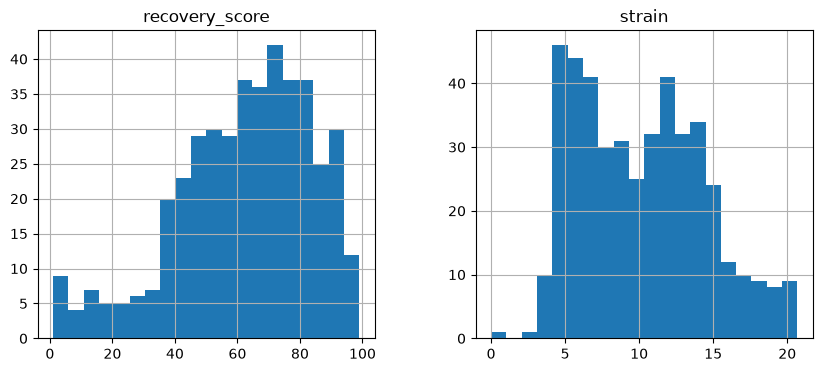

In [4]:
df[["recovery_score", "strain", "hrv_rmssd_milli", "resting_heart_rate"]].describe()
df[["recovery_score", "strain"]].hist(bins=20, figsize=(10, 4))
plt.show()

In [14]:
df[df["recovery_score"] < 15][["date", "recovery_score", "disturbance_count", "awake_hours"]].sort_values("recovery_score")

,date,recovery_score,disturbance_count,awake_hours
410,2026-08-27,1.0,11.0,2.497958
148,2025-11-24,1.0,4.0,1.515177
287,2026-04-14,1.0,2.0,0.141667
411,2026-08-28,1.0,9.0,2.593753
50,2025-08-18,4.0,8.0,0.516936
102,2025-10-08,4.0,4.0,0.175015
404,2026-08-22,4.0,4.0,0.275019
379,2026-07-16,4.0,0.0,0.732837
245,2026-03-02,5.0,3.0,0.292137
202,2026-01-17,6.0,2.0,0.642573


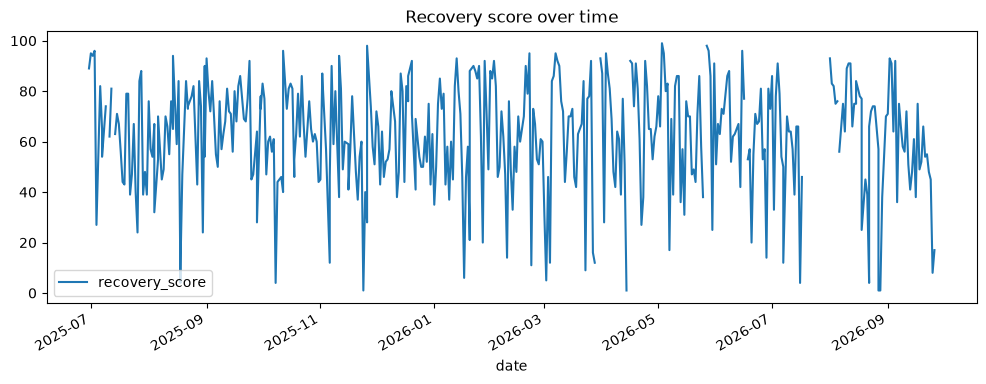

In [5]:
df.plot(x="date", y="recovery_score", figsize=(12, 4), title="Recovery score over time")
plt.show()

In [19]:
window = df[(df["date"] >= pd.to_datetime("2026-07-01")) & (df["date"] <= pd.to_datetime("2026-09-15"))].copy()
window["period"] = window["date"].apply(lambda d: "before_arrival" if d < pd.to_datetime("2026-07-28") else "after_arrival")
window.groupby("period")[["recovery_score", "disturbance_count", "awake_hours"]].describe()

recovery_score                                               \
                        count       mean        std  min   25%   50%   75%   
period                                                                       
after_arrival            45.0  63.800000  23.636066  1.0  56.0  71.0  77.0   
before_arrival           17.0  56.411765  24.054778  4.0  46.0  64.0  70.0   

                     disturbance_count            ...             awake_hours  \
                 max             count      mean  ...   75%   max       count   
period                                            ...                           
after_arrival   93.0              45.0  9.622222  ...  12.0  19.0        45.0   
before_arrival  91.0              17.0  9.764706  ...  12.0  23.0        17.0   

                                                                            \
                    mean       std       min       25%       50%       75%   
period                                                                       
after_arrival   0.591133  0.531254  0.158056  0.275019  0.408906  0.667250   
before_arrival  0.486271  0.267813  0.183333  0.292120  0.442119  0.584194   

                          
                     max  
period                    
after_arrival   2.593753  
before_arrival  1.201783  

[2 rows x 24 columns]